In [1]:
from functools import reduce
import numpy as np

# 1 量子ビットパウリ演算子を行列で定義
pX = np.array([ [0, 1], [1, 0] ])
pY = np.array([ [0, -1j], [1j, 0]] )
pZ = np.array([ [1, 0], [0, -1] ])

# X[0] = X I I ..., Z[1] = I Z I ...
# というn_qubits上の演算子(2^n_qubits次元の行列)のリストを作る
def make_multiqubit_pauli(pauli, n_qubits):
    ret = []
    identity = np.array([ [1, 0], [0, 1] ])
    # [I, I, ..., pauli, I, ...]というリストを作り, numpy.kron で直積をとる
    for i in range(n_qubits):
        paulis_to_tensored = [identity for j in range(n_qubits)]
        paulis_to_tensored[i] = pauli
        ret.append(reduce(np.kron, paulis_to_tensored))
    return ret

n_qubits = 2

X = make_multiqubit_pauli(pX, n_qubits)
Y = make_multiqubit_pauli(pY, n_qubits)
Z = make_multiqubit_pauli(pZ, n_qubits)

In [2]:
# scipy の関数で行列の指数関数を計算する
from scipy.linalg import expm
def RY(target, angle):
    return expm( -0.5j * angle * Y[target])

CNOT = np.array([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]])

In [3]:
ham = 0.011280 * np.dot(Z[0],Z[1]) + 0.397936 * (Z[0] + Z[1]) + 0.180931 * np.dot(X[0],X[1])

In [4]:
def ansatz_two_qubits(params):
    # |00>を準備
    state = np.zeros(4)
    state[0] = 1
    # 量子ゲートを作用，@は行列やベクトルの積を表す
    state = RY(0, params[0]) @ state
    state = RY(1, params[1]) @ state
    state = CNOT @ state
    return state

In [5]:
def cost(params):
    state = ansatz_two_qubits(params)
    return np.real(state.T.conj() @ ham @ state)

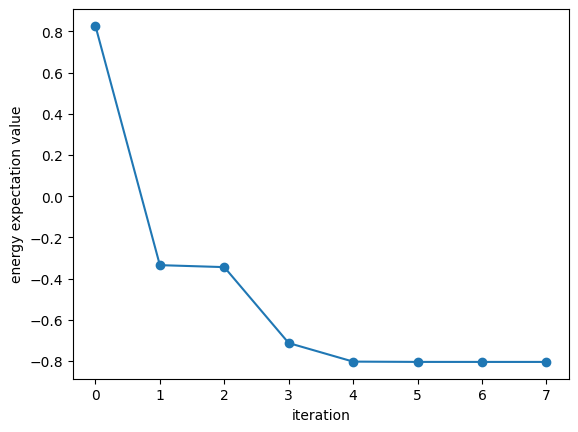

In [6]:
import scipy.optimize
import matplotlib.pyplot as plt

# コスト関数の履歴を保存するためのリストとコールバック関数
cost_val = []
def callback(params):
    global cost_val
    cost_val.append(cost(params))

# 初期値はランダム
rng = np.random.default_rng()
init_params = rng.random(2)
callback(init_params)

# 最小化
res = scipy.optimize.minimize(
    cost, init_params, method='BFGS', callback=callback
)

# プロット
plt.plot(cost_val, "o-")
plt.xlabel("iteration")
plt.ylabel("energy expectation value")
plt.show()

In [7]:
import scipy.linalg
eigs, _ = scipy.linalg.eigh(ham)
print(eigs[0]) # 最小固有値
print(cost_val[-1]) # VQE の結果
print(cost_val[-1] - eigs[0]) # 差 (エネルギー精度)

-0.8048990656130536
-0.8048990656113798
1.673772231924886e-12


-0.822939888009888


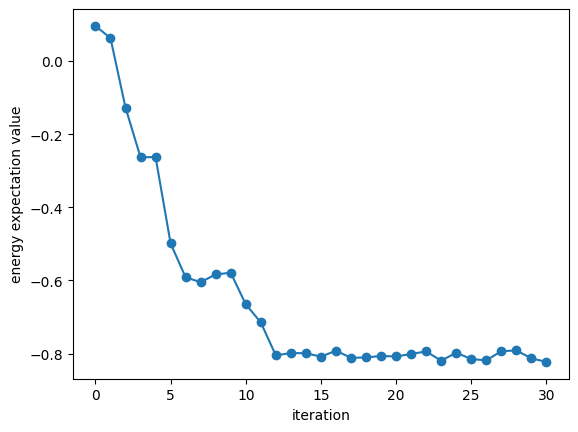

In [8]:
# 平均0, 標準偏差 0.01 の正規分布乱数を加えたコスト関数
def cost_with_noise(params):
    return cost(params) + 0.01 * rng.standard_normal()

def callback_with_noise(params):
    global cost_val_with_noise
    cost_val_with_noise.append(cost_with_noise(params))

cost_val_with_noise = [] # コスト関数の履歴
init_params = rng.random(2)
callback(init_params)
res_with_noise = scipy.optimize.minimize(
    cost_with_noise, init_params, method='COBYLA', callback=callback_with_noise
    )

print(cost_val_with_noise[-1]) # 最適化の結果
plt.plot(cost_val_with_noise, "o-")
plt.xlabel("iteration")
plt.ylabel("energy expectation value")
plt.show()

In [9]:
state = ansatz_two_qubits(res.x)
exp = np.real(state.T.conj() @ np.dot(X[0],X[1]) @ state)
print(exp) # 厳密な期待値

-0.22168243596937134


In [10]:
pHad = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
state_XX = np.kron(pHad, pHad) @ state
probs = np.abs(state_XX)**2 # 各測定結果を得る確率
print(probs)

[0.19457925 0.30542083 0.30542039 0.19457953]


In [11]:
ave_list = []; std_list = []
n_shots_list = [10**i for i in range(2, 10)]
n_trials = 10
for n_shots in n_shots_list:
    est_list = []
    for _ in range(n_trials):
        # 乱数を用いて各測定結果が得られた回数をシミュレート
        counts = rng.multinomial(n_shots, probs)
        # 観測確率から期待値を推定
        est = (counts[0] - counts[1] - counts[2] + counts[3]) / n_shots
        est_list.append(est)
    # 期待値の推定結果の平均と分散を計算
    ave_list.append(float(np.mean(est_list)))
    std_list.append(float(np.std(est_list)))

print(ave_list)

[-0.244, -0.22820000000000001, -0.21947999999999998, -0.221326, -0.22206160000000003, -0.22167132, -0.22168443, -0.2216789244]


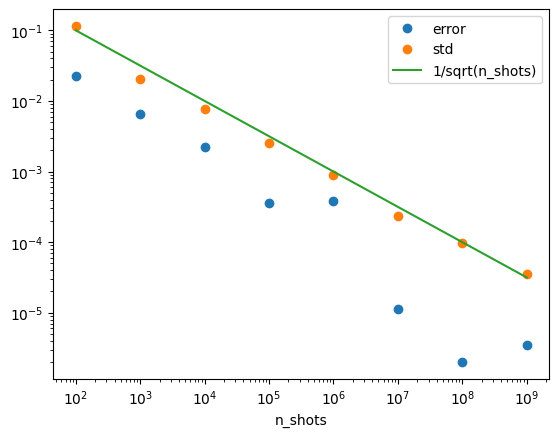

In [12]:
plt.loglog(n_shots_list, np.abs(ave_list-exp), "o", label="error")
plt.loglog(n_shots_list, std_list, "o", label="std")
plt.loglog(n_shots_list, 1/np.sqrt(n_shots_list), label="1/sqrt(n_shots)")
plt.xlabel("n_shots")
plt.legend()
plt.show()